## Pembuatan Model untuk Skripsi

In [1]:
""""
Import Dataset
"""
# Import Library yang diperlukan
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Dibuat Variabel dulu biar mudah diubah
require_score = 400
folder_file = "stringdb_web_tsv_short"
nama_file = f"stringdb_result_{require_score}.tsv"

# Pilih Dataset
dataset = f"{folder_file}/{nama_file}"

# Load Data
df = pd.read_csv(dataset, sep='\t')

# Ambil kolom yang diperlukan
subset = df[["preferredName_A", "preferredName_B", "score"]]

# Buat id untuk gen nya ~ {'ERCC1': 0, 'INPP4A': 1,
nodes = pd.concat([subset["preferredName_A"], subset["preferredName_B"]]).unique()
node_to_id = {node: i for i, node in enumerate(nodes)} 

# buat edge list dalam bentuk id
edges = np.array([
  [node_to_id[a], node_to_id[b]]
    for a, b in zip(df["preferredName_A"], df["preferredName_B"])
])

# Buat adjacency matrix (A) sebagai sparse CSR, graf undirected
num_nodes = len(nodes)

## Edge dari A -> B
row = edges[:, 0]
col = edges[:, 1]
data = df["score"].values # bobot = score

## tambahkan edge dari B → A untuk undirected
row2 = edges[:,1]
col2 = edges[:,0]
data2 = df["score"].values

row = np.concatenate([row, row2])
col = np.concatenate([col, col2])
data = np.concatenate([data, data2])

A = sp.csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))

print("✅ Adjancency matrix (A) didapatkan")


✅ Adjancency matrix (A) didapatkan


In [2]:
"""
Analisis Topologi Awal
1. Density
2. Clustering Coefficient
"""
# Init awal
N = A.shape[0]

# 1. Density
density_baseline = A.nnz / (N**2 - N)
num_triangles = (A @ A @ A).diagonal().sum() / 6
num_possible_triangles = (N - 2) * (N - 1) * N / 6
clust_coef_baseline = num_triangles / num_possible_triangles
print(f'Data Awal (Graf Asli):\n'
      f'Density    = {density_baseline:.4f}\n'
      f'Clustering Coefficient = {clust_coef_baseline:.4f}')

print("\n✅ Analisis Topologi Selesai dilakukan")


Data Awal (Graf Asli):
Density    = 0.0691
Clustering Coefficient = 0.0011

✅ Analisis Topologi Selesai dilakukan


In [3]:
"""
Noermalisasi Matrix Adjasensi
"""
# Import library yang diperlukan
from sklearn.preprocessing import normalize # untuk normalisasi matriks input
import nocd

# Melakukan normalisasi
data_norm = normalize(A)
data_norm = nocd.utils.to_sparse_tensor(data_norm)

print("✅ Data Normalisasi sparse tensor sesuai PyTorch !!! ")

✅ Data Normalisasi sparse tensor sesuai PyTorch !!! 


d:\Kuliah\program-skripsi\temp\overlapping-community-detection\nocd\utils.py:41: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:656.)
  sparse_tensor = torch.sparse.FloatTensor(indices, values, shape)


1. Estimasi Heuristik (Rule of Thumbs) :
17.10263137648707

2. Optimasi Modularitas Multi-Resolution :
Resolution 1.0 -> Ditemukan K = 5 (Avg Size: 117.0 nodes) ~ (modularity : 0.35)
Resolution 1.5 -> Ditemukan K = 12 (Avg Size: 48.8 nodes) ~ (modularity : 0.26)
Resolution 2.0 -> Ditemukan K = 18 (Avg Size: 32.5 nodes) ~ (modularity : 0.21)
Resolution 2.5 -> Ditemukan K = 30 (Avg Size: 19.5 nodes) ~ (modularity : 0.18)
Resolution 3.0 -> Ditemukan K = 42 (Avg Size: 13.9 nodes) ~ (modularity : 0.15)
Resolution 3.5 -> Ditemukan K = 52 (Avg Size: 11.2 nodes) ~ (modularity : 0.13)
Resolution 4.0 -> Ditemukan K = 57 (Avg Size: 10.3 nodes) ~ (modularity : 0.11)
Resolution 4.5 -> Ditemukan K = 70 (Avg Size: 8.4 nodes) ~ (modularity : 0.09)
Resolution 5.0 -> Ditemukan K = 77 (Avg Size: 7.6 nodes) ~ (modularity : 0.08)

3.	Validasi Elbow Method  :


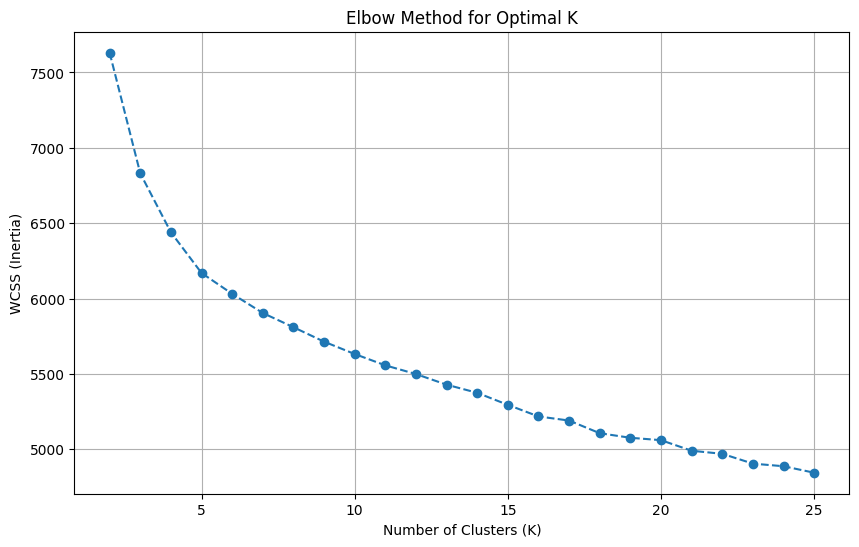

✅ Nilai K dapat disimpulkan 

Nilai K yang dipilih adalah = 16


In [4]:
"""
Mencari Nilai K dengan 3 metode : 
1. Rule of Thumbs
2. Optimasi Modularitas Multi-Resolution
3. Elbow Method
"""
# 1. Rule of Thumbs
# Import library yang dibutuhkan
from math import sqrt

# Perhitungan
jml_nodes = len(nodes)
hasil = sqrt( jml_nodes / 2)
print("1. Estimasi Heuristik (Rule of Thumbs) :")
print(hasil)  

# 2. Optimasi Modularitas Multi-Resolution
# Import library yang dibutuhkan
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Fungsi untuk mencari menjalankan resolusi berbeda
def find_optimal_k(A, resolutions=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]):
    # print("🔍 MENCARI K YANG LEBIH REALISTIS...")
    G_nx = nx.from_scipy_sparse_array(A)
    
    results = []
    
    for res in resolutions:
        # Jalankan Louvain dengan resolusi berbeda
        # Resolution > 1.0 akan memecah komunitas besar menjadi lebih kecil
        comms = nx.community.louvain_communities(G_nx, weight='weight', resolution=res)
        
        k_found = len(comms)
        modularity = nx.community.modularity(G_nx, comms, weight='weight', resolution=res)
        avg_size = np.mean([len(c) for c in comms])
        
        print(f"Resolution {res:.1f} -> Ditemukan K = {k_found} (Avg Size: {avg_size:.1f} nodes) ~ (modularity : {modularity:.2f})")
        results.append((res, k_found))
        
    return results

print("\n2. Optimasi Modularitas Multi-Resolution :")
# Menjalankan fungsi
find_optimal_k(A)

# 3. Elbow Method
# Import library yang dibutuhkan
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
%matplotlib inline

# Menyimpan WCSS untuk setiap K
wcss = []
k_range = range(2, 26)  # Coba K dari 2 sampai 25

# fungsi untuk kmeans nya
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(A) # Masukkan embedding di sini
    wcss.append(kmeans.inertia_) # Ini yang jadi Sumbu Y

# Plotting
print("\n3.	Validasi Elbow Method  :")
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)') # Sumbu X
plt.ylabel('WCSS (Inertia)')         # Sumbu Y
plt.grid(True)
plt.show()

print("✅ Nilai K dapat disimpulkan ")

print("\nNilai K yang dipilih adalah = 16")

In [5]:
"""
Set Hypermarater
"""
hidden_sizes = [128]    # ukuran tersembunyi dari GNN
weight_decay = 1e-2     # kekuatan regularisasi L2 pada bobot GNN (0,01)
dropout = 0.5           # apakah akan menggunakan dropout
batch_norm = True       # apakah akan menggunakan batch_norm
lr = 1e-3               # kecepatan pembelajaran (0,001)
max_epochs = 3000       # jumlah epoch untuk dilatih
display_step = 25       # seberapa sering menghitung validation_loss
balance_loss = True     # apakah akan menggunakan balance_loss
stochastic_loss = True  # apakah akan menggunakan stochastic atau full-batch training
batch_size = 20000      # ukuran batch (hanya untuk pelatihan stokastik)

print("✅ Hypermarater ditetapkan")

✅ Hypermarater ditetapkan


In [6]:
"""
Membangun Model GNN nya
"""
# Import library yang diperlukan
import torch # untuk deep learning

# Menentukan Jumlah Komunitas secara hardcode
K = 16
N = A.shape[0] # Jumlah seluruh node

# Membangun Model
sampler = nocd.sampler.get_edge_sampler(A, batch_size, batch_size, num_workers=4)
gnn = nocd.nn.GCN(data_norm.shape[1], hidden_sizes, K, batch_norm=batch_norm, dropout=dropout)
adj_norm = gnn.normalize_adj(A) 
decoder = nocd.nn.BerpoDecoder(N, A.nnz, balance_loss=balance_loss)
opt = torch.optim.Adam(gnn.parameters(), lr=lr)

print("✅ Persiapan Model GNN selesai ")

✅ Persiapan Model GNN selesai 


In [7]:
"""
Melakukan Training dan Validasi Model GNN
"""
# Import library yang diperlukan
import torch.nn.functional as F

# Training Loop dengan Early Stopping dan Model Saver (set up variabelnya)
val_loss = np.inf
train_loss_current = 0.0
validation_fn = lambda: val_loss
early_stopping = nocd.train.NoImprovementStopping(validation_fn, patience=10)
model_saver = nocd.train.ModelSaver(gnn)

# Proses epoch berjalan
for epoch, batch in enumerate(sampler):
  if epoch > max_epochs:
    break
  if epoch % 25 == 0:
    with torch.no_grad():
      gnn.eval()
      # Hitung "validation loss"
      Z = F.relu(gnn(data_norm, adj_norm))
      val_loss = decoder.loss_full(Z, A)
  
      # Kasih indikator di console
      print(f"Epoch {epoch}: loss.full: {val_loss:.4f}")

      # Periksa apakah sudah waktunya untuk berhenti lebih awal/menyimpan model
      early_stopping.next_step()
      if early_stopping.should_save():
        model_saver.save()
      if early_stopping.should_stop():
        print(f"Breaking due to early stopping at epoch {epoch}")
        break
  
  gnn.train()
  opt.zero_grad()
  Z = F.relu(gnn(data_norm, adj_norm))
  ones_idx, zeros_idx = batch
  if stochastic_loss:
    loss = decoder.loss_batch(Z, ones_idx, zeros_idx)
  else:
    loss = decoder.loss_full(Z, A)
    
  loss = decoder.loss_full(Z, A)
  loss += nocd.utils.l2_reg_loss(gnn, scale=weight_decay)

  loss.backward()
  opt.step()

print("✅ Model GNN selesai di Train")

Epoch 0: loss.full: 0.6120
Epoch 25: loss.full: 0.3544
Epoch 50: loss.full: 0.3284
Epoch 75: loss.full: 0.3322
Epoch 100: loss.full: 0.3125
Epoch 125: loss.full: 0.3085
Epoch 150: loss.full: 0.3050
Epoch 175: loss.full: 0.3039
Epoch 200: loss.full: 0.2974
Epoch 225: loss.full: 0.2971
Epoch 250: loss.full: 0.2930
Epoch 275: loss.full: 0.2949
Epoch 300: loss.full: 0.2936
Epoch 325: loss.full: 0.2921
Epoch 350: loss.full: 0.2929
Epoch 375: loss.full: 0.2924
Epoch 400: loss.full: 0.2919
Epoch 425: loss.full: 0.2936
Epoch 450: loss.full: 0.2887
Epoch 475: loss.full: 0.2901
Epoch 500: loss.full: 0.2906
Epoch 525: loss.full: 0.2889
Epoch 550: loss.full: 0.2886
Epoch 575: loss.full: 0.2888
Epoch 600: loss.full: 0.2894
Epoch 625: loss.full: 0.2872
Epoch 650: loss.full: 0.2906
Epoch 675: loss.full: 0.2896
Epoch 700: loss.full: 0.2881
Epoch 725: loss.full: 0.2898
Epoch 750: loss.full: 0.2864
Epoch 775: loss.full: 0.2861
Epoch 800: loss.full: 0.2886
Epoch 825: loss.full: 0.2862
Epoch 850: loss.ful

In [8]:
"""
Menyimpan Model yang telah di train
"""
# Menyiapkan Config yang digunakan
config_param = {
  'input_dim': data_norm.shape[1],
  'hidden_dims': hidden_sizes,
  'output_dim': K,
  'batch_norm': batch_norm,
  'dropout': dropout,
}

# Menyiapkan checkpoint dari model yang udah di train
checkpoint = {
  'hyperparameters': config_param,
  'model_state': gnn.state_dict() # ini bobot/otaknya
}

# Menyiapkan path folder dan nama file
path_folder = "result_models"
nama_model = f"model_K{K}_dataset{require_score}_short.pth"
final_file = f"{path_folder}/{nama_model}"

# Menimpan Model
torch.save(checkpoint, final_file)

print(f"✅ Model GNN selesai disimpan di '{final_file}' ")

✅ Model GNN selesai disimpan di 'result_models/model_K16_dataset400_short.pth' 


In [9]:
"""
Proses Thresholding 
"""
# Init awal
gnn.eval()
Z_numpy = Z.cpu().detach().numpy()

# Persiapan & Tresholding Awal
thresh = 0.5
Z_pred = Z_numpy > thresh

print(f"✅ Thresholding selesai dilakukan 🌟")

✅ Thresholding selesai dilakukan 🌟


In [10]:

"""
Proses Jaring Pengaman (Safety Net)
= Agar tidak ada node yang "jomblo" (tanpa komunitas)
"""
# Deteksi Node "Jomblo" (Tanpa Komunitas)
num_orphans = Z_pred.sum(axis=1) == 0
print(f"Jumlah node tanpa komunitas awal : {num_orphans.sum()}")

# Untuk node yang "jomblo", ambil indeks dengan nilai Z tertinggi (argmax)
orphan_rows = Z_numpy[num_orphans]
best_community_indices = orphan_rows.argmax(axis=1)

# Update Z_pred: set menjadi true pada indeks komunitas terbaik tersebut
node_indices = np.where(num_orphans)[0]

# Set True secara spesifik
Z_pred[node_indices, best_community_indices] = True
print(f"Jumlah node tanpa komunitas setelah fix: {(Z_pred.sum(axis=1) == 0).sum()} \n")

print(f"✅ Jaring Pengaman (Safety Net) berhasil dilakukan ")


Jumlah node tanpa komunitas awal : 88
Jumlah node tanpa komunitas setelah fix: 0 

✅ Jaring Pengaman (Safety Net) berhasil dilakukan 


In [11]:
"""
Menampilkan Komunitas dan isinya apa aja
"""
# Buat List Komunitas
communities_list = nocd.utils.coms_matrix_to_list(Z_pred)

# Buat Dictionary node to id, untuk menampilkan komunitas nanti
node_names = {node: i for i, node in node_to_id.items()}

# Fungsi untuk memetakan indeks ke nama (PERBAIKAN di sini!)
def map_indices_to_names(index_list, node_names):
    # MENGGUNAKAN LIST COMPREHENSION: mengambil nama untuk setiap indeks dalam list
    return [node_names[index] for index in index_list]

count = 0
for i, community_indices in enumerate(communities_list):
    # Memeriksa apakah komunitas tersebut memiliki anggota
    if len(community_indices) > 0:        
        # community_indices adalah list indeks node
        community_names = map_indices_to_names(community_indices, node_names)
        
        print(f"Komunitas {i+1} (Jumlah Node: {len(community_names)}):")
        
        # Menampilkan node, dibatasi hingga 10 node pertama per komunitas untuk output yang ringkas
        if len(community_names) > 10:
            # Tidak perlu .tolist() lagi karena sudah menjadi list Python
            first_ten_names = community_names[:10] 
            print(f"  {first_ten_names} ... [Total {len(community_names)} node]")
        else:
            print(f"  {community_names}")
        count += 1

print(f"\n\n✅ Data berhasil ditampilkan ")

Komunitas 1 (Jumlah Node: 4):
  ['ALDH2', 'ECT2L', 'EXT2', 'MAP3K6']
Komunitas 2 (Jumlah Node: 83):
  ['ABRAXAS1', 'ARID1A', 'ATM', 'ATMIN', 'ATR', 'ATRX', 'BLM', 'BRCA1', 'BRCA2', 'BRIP1'] ... [Total 83 node]
Komunitas 3 (Jumlah Node: 101):
  ['AJUBA', 'ANKRD11', 'AR', 'ARID1A', 'ARID1B', 'ARID2', 'ARID4B', 'ARID5A', 'ASXL1', 'ATM'] ... [Total 101 node]
Komunitas 4 (Jumlah Node: 102):
  ['ABL1', 'ACTB', 'AGO2', 'AR', 'ARID1A', 'ARID1B', 'ARID2', 'ASXL1', 'ATM', 'ATRX'] ... [Total 102 node]
Komunitas 5 (Jumlah Node: 16):
  ['ADHFE1', 'ALDH1L2', 'ALDH2', 'ATIC', 'CANT1', 'CCNB1IP1', 'DPYD', 'FH', 'GABRA6', 'HTATIP2'] ... [Total 16 node]
Komunitas 6 (Jumlah Node: 100):
  ['ABL1', 'ACTB', 'ALB', 'ALK', 'AXL', 'BCL2', 'BRAF', 'BTK', 'CD28', 'CDC42'] ... [Total 100 node]
Komunitas 7 (Jumlah Node: 72):
  ['ABL1', 'ABL2', 'AFF1', 'ASXL1', 'BCORL1', 'BCR', 'BRD4', 'CALR', 'CBFA2T3', 'CDKN2A'] ... [Total 72 node]
Komunitas 8 (Jumlah Node: 61):
  ['BCL2', 'BTK', 'CARD11', 'CD28', 'CD58', 'CD79B'

In [12]:
"""
Evaluasi Model dengan 4 metrik Unsupervised : 
1. Coverage
2. Conductance
3. Density
4. Clustering Coefficient
"""

print(f'Data Analisis Topologi Awal (Graf Asli):\n'
      f'- density    = {density_baseline:.4f}\n'
      f'- clust_coef = {clust_coef_baseline:.4f}')


# Persiapan Data untuk evaluasi unsupervised
metrics = nocd.metrics.evaluate_unsupervised(Z_pred, A)
print(f"\nHasil Prediksi Komunitas:\n"
      f"- coverage    = {metrics['coverage']:.4f}\n"
      f"- conductance = {metrics['conductance']:.4f}\n"
      f"- density     = {metrics['density']:.4f}\n"
      f"- clust_coef  = {metrics['clustering_coef']:.4f}")

# Kasih pembatas untuk ditampilkan pembantu
print("\n--- Membantu Membaca Evaluasi ----\n")

# Pembantu Evaluasinya
if density_baseline < metrics['density'] :
      print("Densitas : Naik ~ (Makin Rapat) ")
elif density_baseline > metrics['density'] :
      print("Densitas : Turun ~ (Makin Rengang) ")

if clust_coef_baseline < metrics['clustering_coef'] :
      print("Clustering Coefficient : Naik ")
elif clust_coef_baseline > metrics['clustering_coef'] :
      print("Clustering Coefficient : Turun")

# Kasih pembatas untuk ditampilkan
print("\n✅ Evaluasi Unsupervised berhasil dilakukan ")

Data Analisis Topologi Awal (Graf Asli):
- density    = 0.0691
- clust_coef = 0.0011

Hasil Prediksi Komunitas:
- coverage    = 0.8486
- conductance = 0.5552
- density     = 0.3445
- clust_coef  = 0.0324

--- Membantu Membaca Evaluasi ----

Densitas : Naik ~ (Makin Rapat) 
Clustering Coefficient : Naik 

✅ Evaluasi Unsupervised berhasil dilakukan 


In [ ]:
"""
Evaluasi Biologis dengan Enrichment Analysis
= Dengan Libary GProfiler untuk Enrichment Analysisnya
"""
# Import library yang diperlukan
from gprofiler import GProfiler

# Init tool
gp = GProfiler(return_dataframe=True)

# Defini list yang akan dilakukan Enrichment Analysis
gene_list = ["ABL1", "CXCR4", "ABCB1", "TP53", "ARID1A", "ANKRD11"] # Ganti isinya berdasarkan hasil komunitas

# Jalankan Enrichment Analysis
results = gp.profile(
    organism = 'hsapiens',    # Organisme (hsapiens = Human, mmusculus = Mouse)
    query = gene_list,        # List gen yang mau dianalisis
    sources = ['GO:BP', 'GO:MF', 'GO:CC', 'KEGG'], # Sumber data (Biological Process, KEGG, Reactome)
    user_threshold = 0.05,    # Ambang batas signifikansi (p-value)
    no_evidences = False      # Set False agar kita bisa lihat gen apa saja yang overlap
)

# Tampilkan Hasilnya
results.head()

# (Opsional) Simpan hasil nya
path_folder = "result_enrichment_analysis"
nama_file = "result_EA.xlsx"
final_file = f"{path_folder}/{nama_file}"
results.to_excel(final_file, index=False)

# Simpan ke file xlsx
# edges_df = pd.DataFrame(edges, columns=["node_A", "node_B"])
# edges_df.to_excel("edges.xlsx", index=False)

In [ ]:
"""
Perhitungan -log10(p-value) dan menampilkan hasilnya
= Semakin tinggi -log10p nya, semakin kuat fungsi terkait penyakit 
"""
# Import library yang diperlukan
import numpy as np

# Hitung -log10(p-value) menggunakan numpy agar lebih cepat dan stabil
# Kita gunakan -np.log10 pada kolom 'p_value'
results['-log10p'] = -np.log10(results['p_value'])

# Memilih dan mengurutkan kolom yang ingin ditampilkan
# Anda bisa menyesuaikan list di bawah ini dengan nama kolom yang Anda inginkan
display_columns = ['source', 'native', 'name', 'p_value', '-log10p', 'significant', 'description']

# 3. Urutkan berdasarkan -log10p tertinggi (p-value terkecil)
results_sorted = results[display_columns].sort_values(by='-log10p', ascending=False)

# 4. Tampilkan dataframe
# Tampilkan 20 data pertama
results_sorted.head(10)

# (Opsional) Simpan hasil nya
path_folder = "result_enrichment_analysis"
nama_file = "result_EA.xlsx"
final_file = f"{path_folder}/{nama_file}"
results_sorted.to_csv(final_file, index=False)